<a href="https://colab.research.google.com/github/divya-mallapally/Data-science-project-on-Customer-Segmentation-using-K-means/blob/main/Loan_Approval_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Loan_ID": range(1, 21),

    "Gender": [
        "Male","Male","Female","Male","Female",
        "Male","Female","Male","Male","Female",
        "Male","Female","Male","Female","Male",
        "Male","Female","Male","Female","Male"
    ],

    "Married": [
        "Yes","No","Yes","Yes","No",
        "Yes","Yes","No","Yes","No",
        "Yes","Yes","No","Yes","Yes",
        "No","Yes","Yes","No","Yes"
    ],

    "Dependents": [
        0,1,0,2,0,
        1,2,0,3,0,
        1,2,0,1,2,
        0,1,2,0,3
    ],

    "Education": [
        "Graduate","Graduate","Not Graduate","Graduate","Graduate",
        "Graduate","Not Graduate","Graduate","Graduate","Not Graduate",
        "Graduate","Graduate","Graduate","Not Graduate","Graduate",
        "Graduate","Not Graduate","Graduate","Graduate","Graduate"
    ],

    "Self_Employed": [
        "No","No","Yes","No","No",
        "Yes","No","No","Yes","No",
        "No","Yes","No","No","Yes",
        "No","No","Yes","No","No"
    ],

    "ApplicantIncome": [
        5000,3000,2500,7000,4500,
        6000,2800,3500,8000,2200,
        5500,6500,4000,3000,7500,
        4200,2700,6800,3200,9000
    ],

    "CoapplicantIncome": [
        1500,1000,0,2000,1200,
        1800,500,0,2500,800,
        1200,1500,1000,500,2000,
        0,700,1800,900,3000
    ],

    "LoanAmount": [
        150,100,80,200,120,
        180,90,110,250,70,
        140,160,100,90,220,
        130,85,190,105,280
    ],

    "Loan_Amount_Term": [
        360,360,240,360,360,
        360,240,360,360,180,
        360,360,240,360,360,
        240,360,360,240,360
    ],

    "Credit_History": [
        1,1,0,1,1,
        1,0,1,1,0,
        1,1,1,0,1,
        1,0,1,1,1
    ],

    "Property_Area": [
        "Urban","Rural","Semiurban","Urban","Semiurban",
        "Urban","Rural","Semiurban","Urban","Rural",
        "Urban","Semiurban","Rural","Rural","Urban",
        "Semiurban","Rural","Urban","Semiurban","Urban"
    ],

    "Loan_Status": [
        "Y","Y","N","Y","Y",
        "Y","N","Y","Y","N",
        "Y","Y","Y","N","Y",
        "Y","N","Y","Y","Y"
    ]
}

loan_df = pd.DataFrame(data)

loan_df.to_csv(
    "loan_dataset.csv",
    index=False
)

loan_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,Male,Yes,0,Graduate,No,5000,1500,150,360,1,Urban,Y
1,2,Male,No,1,Graduate,No,3000,1000,100,360,1,Rural,Y
2,3,Female,Yes,0,Not Graduate,Yes,2500,0,80,240,0,Semiurban,N
3,4,Male,Yes,2,Graduate,No,7000,2000,200,360,1,Urban,Y
4,5,Female,No,0,Graduate,No,4500,1200,120,360,1,Semiurban,Y


In [3]:
df = pd.read_csv("loan_dataset.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,Male,Yes,0,Graduate,No,5000,1500,150,360,1,Urban,Y
1,2,Male,No,1,Graduate,No,3000,1000,100,360,1,Rural,Y
2,3,Female,Yes,0,Not Graduate,Yes,2500,0,80,240,0,Semiurban,N
3,4,Male,Yes,2,Graduate,No,7000,2000,200,360,1,Urban,Y
4,5,Female,No,0,Graduate,No,4500,1200,120,360,1,Semiurban,Y


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 20
Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            20 non-null     int64 
 1   Gender             20 non-null     object
 2   Married            20 non-null     object
 3   Dependents         20 non-null     int64 
 4   Education          20 non-null     object
 5   Self_Employed      20 non-null     object
 6   ApplicantIncome    20 non-null     int64 
 7   CoapplicantIncome  20 non-null     int64 
 8   LoanAmount         20 non-null     int64 
 9   Loan_Amount_Term   20 non-null     int64 
 10  Credit_History     20 non-null     int64 
 11  Property_Area      20 non-null     object
 12  Loan_Status        20 non-null     object
dtypes: int64(7), object(6)
memory usage: 2.2+ KB


In [5]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [6]:
df = df.dropna()
df = df.drop_duplicates()

print("Data preprocessing completed!")

Data preprocessing completed!


In [7]:
categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [8]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

In [9]:
features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
]

X = df[features]
y = df["Loan_Status"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 16
Testing: 4


In [11]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)

print("Logistic Regression Accuracy:",
      lr_accuracy)

Logistic Regression Accuracy: 1.0


In [12]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)

print("Decision Tree Accuracy:",
      dt_accuracy)

Decision Tree Accuracy: 1.0


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 1.0


In [14]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


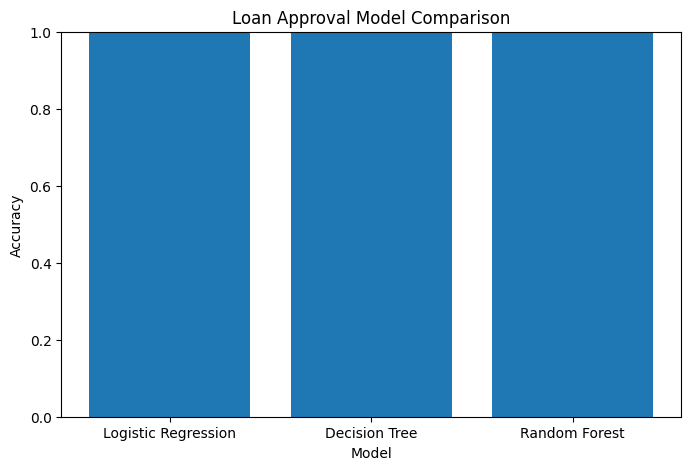

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Loan Approval Model Comparison")

plt.ylim(0,1)

plt.show()

In [17]:
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



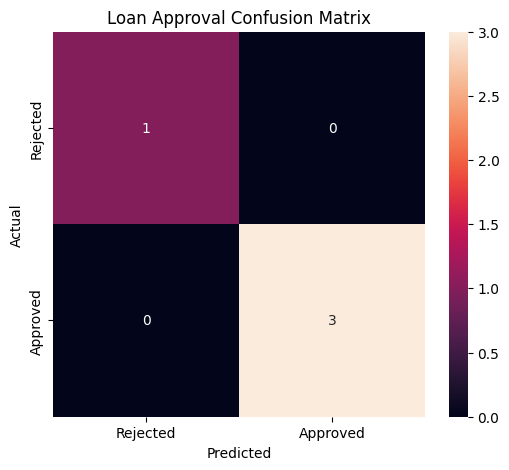

In [18]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Confusion Matrix")

plt.show()

In [19]:
new_applicant = pd.DataFrame({
    "Gender": [1],
    "Married": [1],
    "Dependents": [1],
    "Education": [0],
    "Self_Employed": [0],
    "ApplicantIncome": [6000],
    "CoapplicantIncome": [1500],
    "LoanAmount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Property_Area": [2]
})

In [20]:
prediction = rf_model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Status: APPROVED")
else:
    print("Loan Status: REJECTED")

Loan Status: APPROVED


In [21]:
from google.colab import files

files.download("loan_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>